In [1]:
from torchvision import models
import torch
import torch.nn as nn
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    balanced_accuracy_score,
)
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np


In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parents[0]
sys.path.append(str(ROOT))

from Utils.project_utils import *
import Utils.constants as c
from Utils.transforms import *
from Utils.MushroomDataset import *
from Utils.dataLoaders import *

In [3]:
PROJECT_ROOT = get_project_root()
CLASSES_DIR = PROJECT_ROOT / "Classes"
DATA_DIR = PROJECT_ROOT / "Data"

device = get_device()

Using device: cuda


In [4]:
SPLIT_DIR = DATA_DIR / "splits"

train = pd.read_csv(SPLIT_DIR / "train.csv")
val = pd.read_csv(SPLIT_DIR / "val.csv")
test = pd.read_csv(SPLIT_DIR / "test.csv")

with open(SPLIT_DIR / "class_to_idx.json", "r") as f:
    train_class_to_idx = json.load(f)

### Improved Model - ResNet18 (Toxic-Priority Fine-Tuning)

- prioritize **high recall for toxic**
- keep **macro F1** and **balanced accuracy** strong
- use **weighted cross-entropy** + **layer-wise learning rates**
- save the best model by a **validation priority score**, not plain accuracy


#### Build Data Loaders

In [5]:
train_tfms_medium = get_train_tfms_medium()
val_tfms = get_val_tfms()

In [6]:
CLASSES = sorted(train["class"].unique().tolist())

In [7]:
train_loader = make_loader(train, train_tfms_medium, train_class_to_idx, CLASSES, c.BATCH_SIZE, c.NUM_WORKERS, device, True)
val_loader = make_loader(val, val_tfms, train_class_to_idx, CLASSES, c.BATCH_SIZE, c.NUM_WORKERS, device, False)
test_loader = make_loader(test, val_tfms, train_class_to_idx, CLASSES, c.BATCH_SIZE, c.NUM_WORKERS, device, False)

In [8]:
toxic_idx = train_class_to_idx["toxic"]

train_counts = train["class"].value_counts()
counts = np.array([train_counts.get(cls, 0) for cls in CLASSES], dtype=np.float32)

# inverse-frequency base weights
base_weights = counts.sum() / (len(CLASSES) * counts)
base_weights = base_weights / base_weights.mean()

# emphasize toxic a bit more to improve toxic recall
toxic_multiplier = 1.75
base_weights[toxic_idx] *= toxic_multiplier

class_weights = torch.tensor(base_weights, dtype=torch.float32, device=device)
print("class weights:", dict(zip(CLASSES, np.round(base_weights, 3))))

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.05,
)


class weights: {'conditionally_edible': 1.0, 'edible': 1.0, 'toxic': 1.75}


#### Training and Validation

In [9]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(device)

optimizer = torch.optim.AdamW(
    [
        {"params": model.conv1.parameters(), "lr": 1e-5},
        {"params": model.bn1.parameters(), "lr": 1e-5},
        {"params": model.layer1.parameters(), "lr": 1e-5},
        {"params": model.layer2.parameters(), "lr": 3e-5},
        {"params": model.layer3.parameters(), "lr": 5e-5},
        {"params": model.layer4.parameters(), "lr": 1e-4},
        {"params": model.fc.parameters(), "lr": 1e-3},
    ],
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2, min_lr=1e-6
)


In [10]:
BEST_MODEL_PATH = Path.cwd() / "best_models" / "resnet18_toxic_priority_best.pth"
BEST_MODEL_PATH

PosixPath('/home/xuy001/teams/z8/data.science/04_Model/best_models/resnet18_toxic_priority_best.pth')

In [11]:
def run_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
    scaler=None,
    is_train=False,
    return_preds=False,
):
    running_loss = 0.0
    running_correct = 0
    total = 0

    d = device if isinstance(device, torch.device) else torch.device(device)
    use_amp = (d.type == "cuda") and (scaler is not None)

    all_preds, all_labels = [], []

    if is_train:
        model.train()
        for img, labels in loader:
            img = img.to(d, non_blocking=True)
            labels = labels.to(d, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            if use_amp:
                with torch.cuda.amp.autocast(True):
                    outputs = model(img)
                    loss = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(img)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            preds = outputs.argmax(1)
            running_loss += loss.item() * img.size(0)
            running_correct += (preds == labels).sum().item()
            total += img.size(0)

            if return_preds:
                all_preds.append(preds.cpu())
                all_labels.append(labels.cpu())
    else:
        model.eval()
        with torch.no_grad():
            for img, labels in loader:
                img = img.to(d, non_blocking=True)
                labels = labels.to(d, non_blocking=True)

                outputs = model(img)
                loss = criterion(outputs, labels)

                preds = outputs.argmax(1)
                running_loss += loss.item() * img.size(0)
                running_correct += (preds == labels).sum().item()
                total += img.size(0)

                if return_preds:
                    all_preds.append(preds.cpu())
                    all_labels.append(labels.cpu())

    total_loss = running_loss / max(total, 1)
    total_acc = running_correct / max(total, 1)

    if return_preds:
        return total_loss, total_acc, total, torch.cat(all_labels), torch.cat(all_preds)
    else:
        return total_loss, total_acc, total, None, None

In [12]:
def evaluate_priority_metrics(model, loader, criterion, optimizer, device, classes, toxic_label="toxic"):
    val_loss, val_acc, _, y_true, y_pred = run_one_epoch(
        model,
        loader,
        criterion,
        optimizer,
        device,
        is_train=False,
        return_preds=True,
    )

    report = classification_report(
        y_true,
        y_pred,
        target_names=classes,
        output_dict=True,
        zero_division=0,
    )

    metrics = {
        "val_loss": val_loss,
        "val_acc": val_acc,
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "toxic_precision": report[toxic_label]["precision"],
        "toxic_recall": report[toxic_label]["recall"],
        "toxic_f1": report[toxic_label]["f1-score"],
    }

    # prioritize toxic recall, but keep global performance healthy
    metrics["priority_score"] = (
        0.55 * metrics["toxic_recall"]
        + 0.30 * metrics["macro_f1"]
        + 0.15 * metrics["balanced_acc"]
    )

    return metrics, y_true, y_pred


def train_finetune(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs,
    device,
    best_model_path,
    patience=5,
    scheduler=None,
    classes=None,
    toxic_label="toxic",
):
    best_score = -float("inf")
    bad_epochs = 0
    history = []

    d = device if isinstance(device, torch.device) else torch.device(device)
    use_amp = d.type == "cuda"
    print("device =", d)
    print("use_amp =", use_amp)

    scaler = torch.cuda.amp.GradScaler(enabled=use_amp) if use_amp else None

    best_model_path = Path(best_model_path)
    best_model_path.parent.mkdir(parents=True, exist_ok=True)

    for epoch in range(num_epochs):
        print(f"\n>>> Fine-tune Epoch {epoch + 1} start", flush=True)

        train_loss, train_acc, _, _, _ = run_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            d,
            scaler=scaler,
            is_train=True,
            return_preds=False,
        )

        val_metrics, _, _ = evaluate_priority_metrics(
            model,
            val_loader,
            criterion,
            optimizer,
            d,
            classes,
            toxic_label=toxic_label,
        )

        if scheduler is not None:
            scheduler.step(val_metrics["priority_score"])

        current_lrs = [pg["lr"] for pg in optimizer.param_groups]

        history.append(
            {
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "train_acc": train_acc,
                **val_metrics,
                "last_lr": current_lrs[-1],
            }
        )

        print(
            f"Epoch {epoch + 1}: "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
            f"val_acc={val_metrics['val_acc']:.4f}, "
            f"balanced_acc={val_metrics['balanced_acc']:.4f}, "
            f"macro_f1={val_metrics['macro_f1']:.4f}, "
            f"toxic_precision={val_metrics['toxic_precision']:.4f}, "
            f"toxic_recall={val_metrics['toxic_recall']:.4f}, "
            f"toxic_f1={val_metrics['toxic_f1']:.4f}, "
            f"priority_score={val_metrics['priority_score']:.4f}, "
            f"last_lr={current_lrs[-1]:.2e}"
        )

        if val_metrics["priority_score"] > best_score:
            best_score = val_metrics["priority_score"]
            bad_epochs = 0
            torch.save(model.state_dict(), best_model_path)
            print(">>> Saved best model (by toxic-priority score)", flush=True)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print("Early stopping triggered (priority_score).", flush=True)
                break

    model.load_state_dict(torch.load(best_model_path, map_location=d))
    return model, pd.DataFrame(history)


In [13]:
model, finetune_history = train_finetune(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=20,
    device=device,
    best_model_path=BEST_MODEL_PATH,
    patience=5,
    scheduler=scheduler,
    classes=CLASSES,
    toxic_label="toxic",
)

finetune_history

device = cuda
use_amp = True

>>> Fine-tune Epoch 1 start
Epoch 1: train_loss=0.6475, train_acc=0.7307, val_acc=0.8101, balanced_acc=0.8101, macro_f1=0.8095, toxic_precision=0.8421, toxic_recall=0.8767, toxic_f1=0.8591, priority_score=0.8465, last_lr=1.00e-03
>>> Saved best model (by toxic-priority score)

>>> Fine-tune Epoch 2 start
Epoch 2: train_loss=0.5189, train_acc=0.8125, val_acc=0.8340, balanced_acc=0.8340, macro_f1=0.8333, toxic_precision=0.8877, toxic_recall=0.8611, toxic_f1=0.8742, priority_score=0.8487, last_lr=1.00e-03
>>> Saved best model (by toxic-priority score)

>>> Fine-tune Epoch 3 start
Epoch 3: train_loss=0.4659, train_acc=0.8430, val_acc=0.8360, balanced_acc=0.8360, macro_f1=0.8355, toxic_precision=0.8401, toxic_recall=0.9060, toxic_f1=0.8718, priority_score=0.8743, last_lr=1.00e-03
>>> Saved best model (by toxic-priority score)

>>> Fine-tune Epoch 4 start
Epoch 4: train_loss=0.4262, train_acc=0.8687, val_acc=0.8423, balanced_acc=0.8423, macro_f1=0.8424, toxic_pr

,epoch,train_loss,train_acc,val_loss,val_acc,balanced_acc,macro_f1,weighted_f1,toxic_precision,toxic_recall,toxic_f1,priority_score,last_lr
0,1,0.647457,0.730740,0.529366,0.810087,0.810087,0.809457,0.809457,0.842105,0.876712,0.859060,0.846542,0.0010
1,2,0.518896,0.812528,0.507706,0.833956,0.833956,0.833341,0.833341,0.887677,0.861146,0.874210,0.848726,0.0010
2,3,0.465937,0.843042,0.496017,0.836032,0.836032,0.835513,0.835513,0.840069,0.905978,0.871780,0.874346,0.0010
3,4,0.426159,0.868653,0.486897,0.842258,0.842258,0.842438,0.842438,0.862733,0.892279,0.877257,0.869824,0.0010
4,5,0.395114,0.886401,0.483156,0.852428,0.852428,0.851908,0.851908,0.871027,0.887298,0.879087,0.871450,0.0010
5,6,0.362040,0.903941,0.474946,0.848692,0.848692,0.848144,0.848144,0.838252,0.919676,0.877078,0.887569,0.0010
6,7,0.333947,0.918732,0.475199,0.858447,0.858447,0.858248,0.858248,0.871933,0.907223,0.889228,0.885214,0.0010
7,8,0.310716,0.932977,0.475191,0.863844,0.863844,0.863499,0.863499,0.878419,0.899751,0.888957,0.883489,0.0010
8,9,0.296327,0.939879,0.450240,0.867787,0.867787,0.867333,0.867333,0.868421,0.924658,0.895657,0.898930,0.0010
9,10,0.283309,0.947612,0.477562,0.860315,0.860315,0.859991,0.859991,0.863022,0.914072,0.887814,0.889784,0.0010


In [14]:
ft_test_loss, ft_test_acc, ft_test_total, ft_test_labels, ft_test_preds = run_one_epoch(
    model,
    test_loader,
    criterion,
    optimizer,
    device,
    is_train=False,
    return_preds=True,
)

test_report = classification_report(
    ft_test_labels,
    ft_test_preds,
    target_names=CLASSES,
    output_dict=True,
    zero_division=0,
)

test_metrics = pd.DataFrame(
    [
        {
            "accuracy": test_report["accuracy"],
            "balanced_accuracy": balanced_accuracy_score(ft_test_labels, ft_test_preds),
            "macro_f1": test_report["macro avg"]["f1-score"],
            "weighted_f1": test_report["weighted avg"]["f1-score"],
            "toxic_precision": test_report["toxic"]["precision"],
            "toxic_recall": test_report["toxic"]["recall"],
            "toxic_f1": test_report["toxic"]["f1-score"],
        }
    ]
)

In [15]:
print("Key test metrics for toxic-priority fine-tuning:")
display(test_metrics.round(4))

Key test metrics for toxic-priority fine-tuning:


,accuracy,balanced_accuracy,macro_f1,weighted_f1,toxic_precision,toxic_recall,toxic_f1
0,0.8555,0.8555,0.8552,0.8552,0.8597,0.9041,0.8813


In [16]:
cm = confusion_matrix(ft_test_labels, ft_test_preds)
print("Confusion matrix:\n", cm)

print("\nClassification report:\n")
print(classification_report(ft_test_labels, ft_test_preds, target_names=CLASSES, digits=4))

Confusion matrix:
 [[1349  164   92]
 [ 141 1320  145]
 [  75   79 1452]]

Classification report:

                      precision    recall  f1-score   support

conditionally_edible     0.8620    0.8405    0.8511      1605
              edible     0.8445    0.8219    0.8331      1606
               toxic     0.8597    0.9041    0.8813      1606

            accuracy                         0.8555      4817
           macro avg     0.8554    0.8555    0.8552      4817
        weighted avg     0.8554    0.8555    0.8552      4817



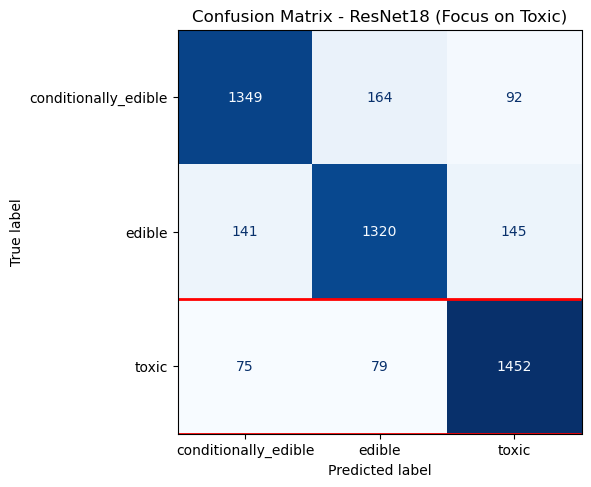

In [17]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Confusion Matrix - ResNet18 (Focus on Toxic)")

# highlight toxic row
toxic_idx = CLASSES.index("toxic")
ax.hlines(toxic_idx - 0.5, -0.5, len(CLASSES)-0.5, colors="red", linewidth=2)
ax.hlines(toxic_idx + 0.5, -0.5, len(CLASSES)-0.5, colors="red", linewidth=2)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "Graphs" / "resnet18_ft_toxic_confusion_matrix.png",
    dpi=300
)

plt.show()

#### Sample Toxic Classes Misclassified to Other Classes

In [18]:
test_df = test_loader.dataset.df
test_df['pred'] = [CLASSES[i] for i in ft_test_preds]
misclassified_toxic = test_df[(test_df['class'] == 'toxic') & (test_df['pred'] != 'toxic')]
misclassified_toxic.pred.value_counts(normalize=True)

pred
edible                  0.512987
conditionally_edible    0.487013
Name: proportion, dtype: float64

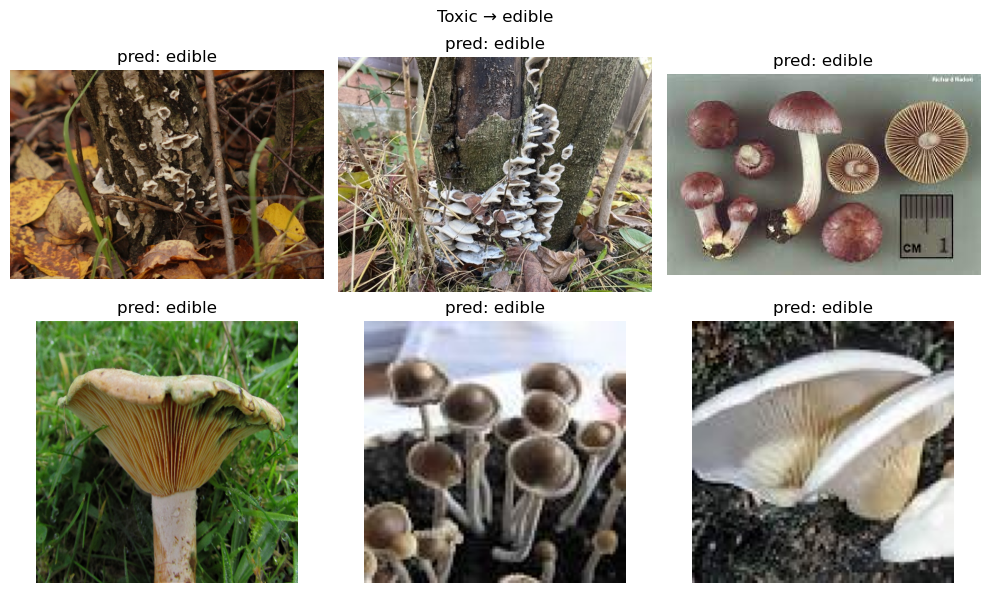

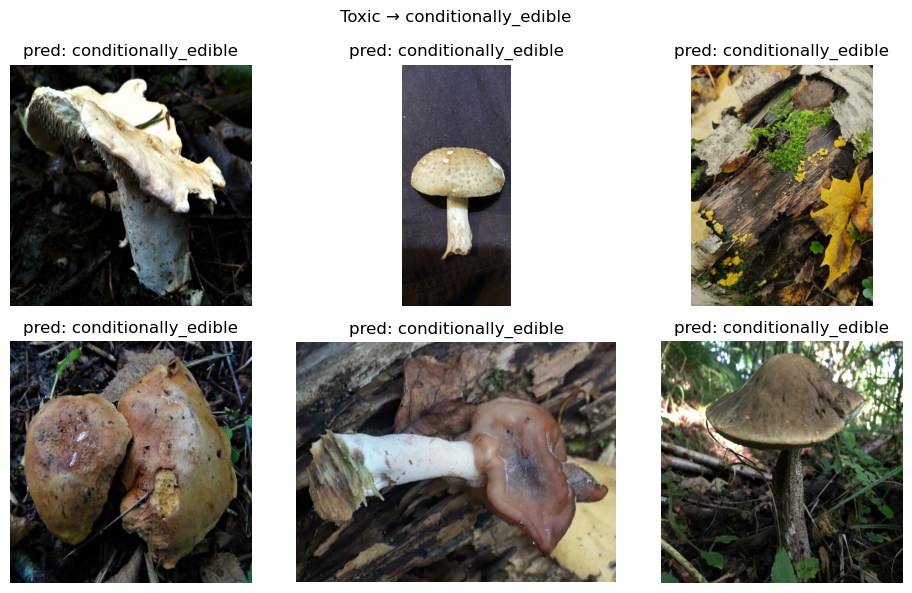

In [19]:
for wrong_pred in ['edible', 'conditionally_edible']:
    
    subset = misclassified_toxic[misclassified_toxic['pred'] == wrong_pred]
    sample = subset.sample(6, random_state=42)
    
    plt.figure(figsize=(10,6))
    
    for i, (_, row) in enumerate(sample.iterrows()):
        plt.subplot(2,3,i+1)
        img = Image.open(CLASSES_DIR / row['file_path'])
        plt.imshow(img)
        plt.title(f"pred: {wrong_pred}")
        plt.axis("off")
    
    plt.suptitle(f"Toxic → {wrong_pred}")
    plt.tight_layout()
    plt.show()